In [1]:
import numpy as np
import pandas as pd
from pandas import Timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error 

from sklearn.preprocessing import MinMaxScaler

from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import load_model

from scipy import signal
%matplotlib inline

plt.style.use('Solarize_Light2')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
!pwd
!ls -R

/content
.:
drive  lstm_17features_2024_2025_24to24_1feb_weights.npz  sample_data

./drive:
MyDrive

./drive/MyDrive:
 1401Kurzbewerbung.pdf
 1528288264341027.pdf
 2021_05_28_ЭкскурсияМамаеваСлобода
 241001_Standardaufnahme_web_Einzel.pdf
'Annex KOICA.pdf'
'Business trips.gsheet'
'Colab Notebooks'
 CV
'CV - Oleksii Leshchenko (October 2023).pdf'
 CV_O.Leshchenko_ComDir.pdf
 CV_O.Leshchenko_CommsProf.pdf
 CV_O.Leshchenko_Google.pdf
'Distribution List.gsheet'
'Energy ID Solutions.gsite'
'Energy Prices Prediction.gslides'
'Germany'\''s Electroenergy Market Overview'$'\n''.gdoc'
'GI logo (1).jpg'
'GI logo (2).jpg'
'GI logo.jpg'
'GI logo (small) (1).jpg'
'GI logo (small).jpg'
'https: 1drv.ms b s!Ao3SGyFMrw11vxFNdon7uO5D6YCA.txt'
 HUR
'HUR (1)'
'I have these results of two models: SARIMAX and A....gsheet'
 Ihor_3.0
'Ihre Einsatzmeldung befindet sich im Anhang.PDF'
 Iphone
'ixv-mcno-wgq – 26 янв. 2022 г. (1).pdf'
'ixv-mcno-wgq – 26 янв. 2022 г..pdf'
 Jan-Feb2019.doc
 keys
 lb_002130_0710_o_tr

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Loading the raw final DataFrame from Google Dreive
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/02_4_clean_data.csv')

In [5]:
# Loading the raw final DataFrame
#df = pd.read_csv(r'..\..\data_cleaned\merged\02_4_clean_data.csv')

In [3]:
# Converting date columns to datetime and filtering for 2019-2024 period

df['date'] = pd.to_datetime(df['date'])
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'])

start_date_df = '2024-01-01'
end_date_df = '2025-12-31'
df = df.query("date >= @start_date_df")
df = df.query("date <= @end_date_df")

print (df['load_forecast_da'].isna().sum())
print (df.columns)

0
Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'dayofweek',
       'price', 'period_start_utc', 'period_end_utc', 'load_forecast_da',
       'off_wind_da', 'on_wind_da', 'solar_da', 'gen_forecast_da',
       'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1',
       'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
       'day_type', 'price_gas'],
      dtype='object')


In [4]:
# Ensure timestamp index
df.set_index('period_start_utc', inplace=True)

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2019-2025')

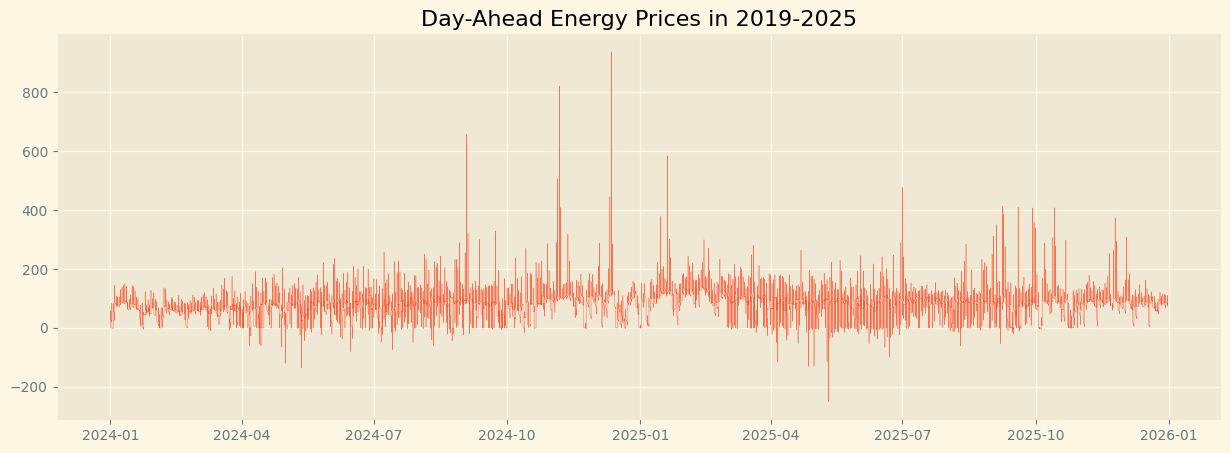

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['price'], label='Price', color=NF_ORANGE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2019-2025')

## LSTM
<p> Last layer has 1/24/168 output neurons - predicting next 1/24/168 hours at once. Using only price for predicting.
<p> Experimenting with various output layers: 1, 24, 168

In [6]:
# 2. Add residual_load = load - RES and dummies for a year

df["residual_load"] = (
    df["load_forecast_da"]
    - df["off_wind_da"]
    - df["on_wind_da"]
    - df["solar_da"]
)

df["year"] = df["date"].dt.year
df = pd.get_dummies(df, columns=["year"], drop_first=True, dtype=int)
df.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas',
       'residual_load', 'year_2025'],
      dtype='object')

In [7]:
# Splitting into train and test sets before normalizing

df['date'] = pd.to_datetime(df['date']).dt.tz_localize('UTC')

split_date = pd.Timestamp('2025-02-01', tz='UTC')

train_df = df[df['date'] < split_date]
test_df = df[df['date'] >= split_date]

train_df.shape, test_df.shape

((9528, 25), (8015, 25))

In [10]:
# The target we want to predict
target_col = ['price']

# High-range features that need scaling
scale_features = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'price_gas']

# Features already in a good range (0 to 1 or -1 to 1)
pass_features = [
    'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 
    'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
    #'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024',
    'year_2025'
]

all_features = target_col + scale_features + pass_features

In [11]:
# Create two separate scalers
target_scaler = MinMaxScaler(feature_range=(-1, 1))
feature_scaler = MinMaxScaler(feature_range=(-1, 1))

# Copy dataframes
scaled_train = train_df[all_features].copy()
scaled_test = test_df[all_features].copy()

# 1. Scale the Price (Target)
scaled_train[target_col] = target_scaler.fit_transform(train_df[target_col])
scaled_test[target_col] = target_scaler.transform(test_df[target_col])

# 2. Scale the High-Magnitude Features
scaled_train[scale_features] = feature_scaler.fit_transform(train_df[scale_features])
scaled_test[scale_features] = feature_scaler.transform(test_df[scale_features])

# 3. Pass-through features remain as is (they are already scaled/binary)

# Convert to Numpy for LSTM
scaled_train_arr = scaled_train.values
scaled_test_arr = scaled_test.values

In [ ]:
# Identifying features that are used for training and the target variable
'''
features = [
    'price',
    'load_forecast_da',
    'res_sum_da',
    'gen_forecast_da',
    'dayofyear_sin1',
    'dayofyear_cos1',
    'hour_sin1',
    'hour_cos1',
    'dayofweek_sin1',
    'dayofweek_cos1',
    'is_holiday',
    'price_gas',
    'year_2020',
    'year_2021',
    'year_2022',
    'year_2023',
    'year_2024',
    'year_2025'
]
'''

In [12]:
scaled_train_arr.shape, scaled_test_arr.shape

((9528, 13), (8015, 13))

In [13]:
# Create sequences

# 1. Update Lookback to 1 week
lookback = 24  # 7 days * 24 hours

# --- TRAIN SEQUENCES ---
X_train, y_train = [], []
# We still want to predict the next 24 hours
prediction_window = 24

for i in range(lookback, len(scaled_train_arr) - prediction_window):
    # X: The previous 168 hours of data (all features)
    X_train.append(scaled_train_arr[i - lookback:i])
    # y: The next 24 hours of price (column index 0)
    y_train.append(scaled_train_arr[i:i + prediction_window, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# --- TEST SEQUENCES ---
X_test, y_test = [], []
for i in range(lookback, len(scaled_test_arr) - prediction_window):
    X_test.append(scaled_test_arr[i - lookback:i])
    y_test.append(scaled_test_arr[i:i + prediction_window, 0])

X_test, y_test = np.array(X_test), np.array(y_test)

print(f"X_train shape: {X_train.shape}") # Should be (Samples, 168, 18)
print(f"y_train shape: {y_train.shape}") # Should be (Samples, 24)

X_train shape: (9480, 24, 13)
y_train shape: (9480, 24)


In [14]:
# Building the LSTM model

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(lookback, X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(prediction_window)  # predicting __ hours (_ day) at once
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,672 (483.09 KB)

 Trainable params: 123,672 (483.09 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model
training = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1039 - val_loss: 0.0122
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0155 - val_loss: 0.0110
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0119 - val_loss: 0.0175
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0096 - val_loss: 0.0105
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0083 - val_loss: 0.0091
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0081 - val_loss: 0.0129
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0070 - val_loss: 0.0126
Epoch 8/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0063 - val_loss: 0.0583
Epoch 9/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0060 - val_loss: 0.0512
Epoch 10/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - val_loss: 0.0178
Epoch 11/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0053 - val_loss: 0.0225
Epoch 12/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/s

### Loading pretrained on Google Colab model (ignore this if you trained model locally)

In [11]:
# Load the archive
with np.load(r'models\lstm_24to24_model_weights.npz') as data:
    # Reconstruct the list of weights in order
    weights_list = [data[f'arr_{i}'] for i in range(len(data.files))]

# Inject the numbers into your local model
model.set_weights(weights_list)

### Saving model

In [16]:
weights = model.get_weights()
# We use the * operator to unpack the list into the saver
np.savez('lstm_17features_2024_2025_24to24_1feb_weights.npz', *weights)

In [16]:
# 1. Predict
y_pred = model.predict(X_test) # Output shape is (Samples, 168)

# 2. Inverse transform the entire 24-hour block at once
# target_scaler expects 2D input. Since it was fitted on 1 column, 
# we treat the 24 hours as 24 separate 'samples' to un-scale them all.

# We reshape to a single column to un-scale, then reshape back to (Samples, 24)
y_pred_inv_full = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1, prediction_window)
y_test_inv_full = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, prediction_window)

print("Full 24-hour inverse transformation complete using dedicated target_scaler.")

249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Full 24-hour inverse transformation complete using dedicated target_scaler.


In [17]:
y_pred_inv_full.shape, y_test_inv_full.shape
y_pred_inv_full[:5], y_test_inv_full[:5]

(array([[127.66712 , 130.50995 , 120.2393  , 126.519135, 120.06204 ,
         104.796295, 118.72691 , 112.23373 , 101.04149 ,  95.13386 ,
          94.85693 ,  93.028305, 102.2746  ,  94.28847 ,  95.847206,
         110.23351 , 114.3937  , 117.44411 , 107.90029 , 110.14296 ,
         107.56911 , 110.48718 ,  80.926735,  85.63214 ],
        [126.2761  , 131.65205 , 122.21953 , 129.0867  , 123.36774 ,
         107.24986 , 121.851036, 114.8186  , 102.68742 ,  95.76058 ,
          95.69597 ,  94.4879  , 105.2554  ,  97.70873 ,  98.893326,
         112.27838 , 113.209305, 112.96994 , 101.40388 , 102.25949 ,
          99.0851  , 103.102066,  74.49049 ,  81.73769 ],
        [127.97953 , 135.87039 , 126.39549 , 132.96149 , 127.30431 ,
         109.697365, 124.68172 , 117.38559 , 105.09506 ,  97.319   ,
          97.799446,  97.72176 , 109.29821 , 101.4445  , 101.5156  ,
         112.91443 , 109.998116, 106.588326,  93.66544 ,  94.16007 ,
          91.93094 ,  98.01619 ,  71.85934 ,  82.40096 ]

In [18]:
for h in range(prediction_window):
    rmse_h = np.sqrt(mean_squared_error(y_test_inv_full[:, h], y_pred_inv_full[:, h]))
    print(f'Hour t+{h+1:03d} -> RMSE: {rmse_h:.2f}')

Hour t+001 -> RMSE: 32.65
Hour t+002 -> RMSE: 35.78
Hour t+003 -> RMSE: 36.93
Hour t+004 -> RMSE: 39.02
Hour t+005 -> RMSE: 40.43
Hour t+006 -> RMSE: 41.77
Hour t+007 -> RMSE: 43.21
Hour t+008 -> RMSE: 43.20
Hour t+009 -> RMSE: 45.18
Hour t+010 -> RMSE: 45.55
Hour t+011 -> RMSE: 45.63
Hour t+012 -> RMSE: 45.43
Hour t+013 -> RMSE: 44.48
Hour t+014 -> RMSE: 44.68
Hour t+015 -> RMSE: 46.19
Hour t+016 -> RMSE: 49.13
Hour t+017 -> RMSE: 48.72
Hour t+018 -> RMSE: 50.74
Hour t+019 -> RMSE: 52.29
Hour t+020 -> RMSE: 51.76
Hour t+021 -> RMSE: 52.55
Hour t+022 -> RMSE: 53.34
Hour t+023 -> RMSE: 48.87
Hour t+024 -> RMSE: 47.67


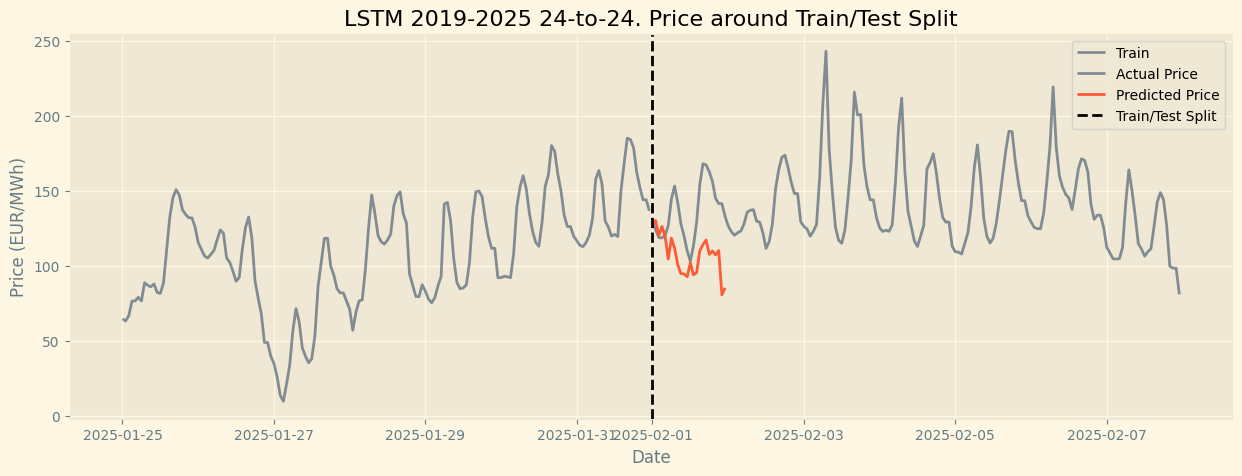

In [26]:
hours_xdays = 21 * 24

hours_xdays = pd.Timedelta(days=7)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv_full[:336:168]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]


plt.figure(figsize=(15, 5))
plt.plot(train_portion.index, train_portion['price'], label='Train', color= NF_BLUE, alpha=0.5)
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color= NF_BLUE, alpha=0.5)
plt.plot(pred_index[:prediction_window], y_pred_inv_full.flatten()[:prediction_window], label='Predicted Price', color=NF_ORANGE)
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('LSTM 2019-2025 24-to-24. Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

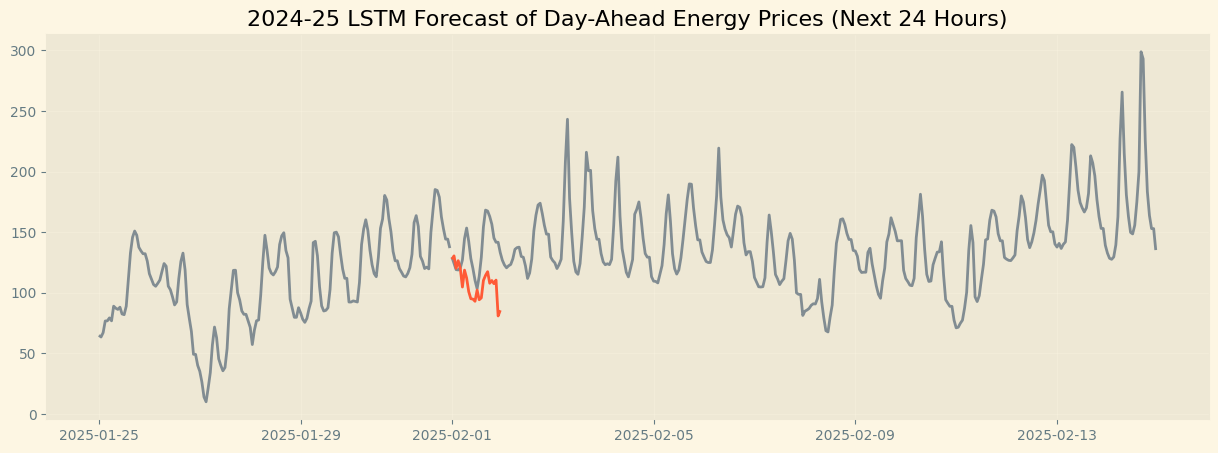

In [27]:
# 1. Define the ranges to match the graph
history_range = pd.Timedelta(days=7)
future_range = pd.Timedelta(days=14) # Graph shows roughly 2 weeks of test data

# 2. Slice the data
train_portion = df.loc[(df.index >= split_date - history_range) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + future_range)]

# 3. Prepare prediction data (First 24 hours)
# Assuming y_pred_inv contains your hourly predictions starting at split_date
n_steps = 24
y_pred_plot = y_pred_inv_full.flatten()[:n_steps]
pred_index = df.loc[split_date : ].index[:n_steps]

# 4. Plotting
plt.figure(figsize=(15, 5))

# Plot Historical (Lower alpha, matches NF_BLUE)
plt.plot(train_portion.index, train_portion['price'], label='Historical', color=NF_BLUE, alpha=0.5)

# Plot Actual Test (Continuing the line)
plt.plot(test_portion.index, test_portion['price'], label='Actual', color=NF_BLUE, alpha=0.5)

# Plot Prediction (Specific 24-hour window)
plt.plot(pred_index, y_pred_plot, label='Predicted', color=NF_ORANGE, linewidth=2)

# Optional: Add the confidence interval shading if you have it for LSTM 
# (Note: LSTMs don't provide this by default like SARIMAX does)

plt.title('2024-25 LSTM Forecast of Day-Ahead Energy Prices (Next 24 Hours)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
test_portion.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_end_utc,load_forecast_da,off_wind_da,...,is_holiday,day_type,price_gas,residual_load,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2025-02-01 00:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,0,5,129.42,2025-02-01 01:00:00+00:00,47770.4800,502.1050,...,0,weekend,53.237,42112.2800,0,0,0,0,0,1
2025-02-01 01:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,1,5,124.24,2025-02-01 02:00:00+00:00,46513.0225,524.8025,...,0,weekend,53.237,41099.9950,0,0,0,0,0,1
2025-02-01 02:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,2,5,119.12,2025-02-01 03:00:00+00:00,45863.2050,568.4375,...,0,weekend,53.237,40667.2975,0,0,0,0,0,1
2025-02-01 03:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,3,5,118.86,2025-02-01 04:00:00+00:00,46343.3425,578.1300,...,0,weekend,53.237,41346.4750,0,0,0,0,0,1
2025-02-01 04:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,4,5,120.54,2025-02-01 05:00:00+00:00,46981.5250,548.9000,...,0,weekend,53.237,42113.4050,0,0,0,0,0,1


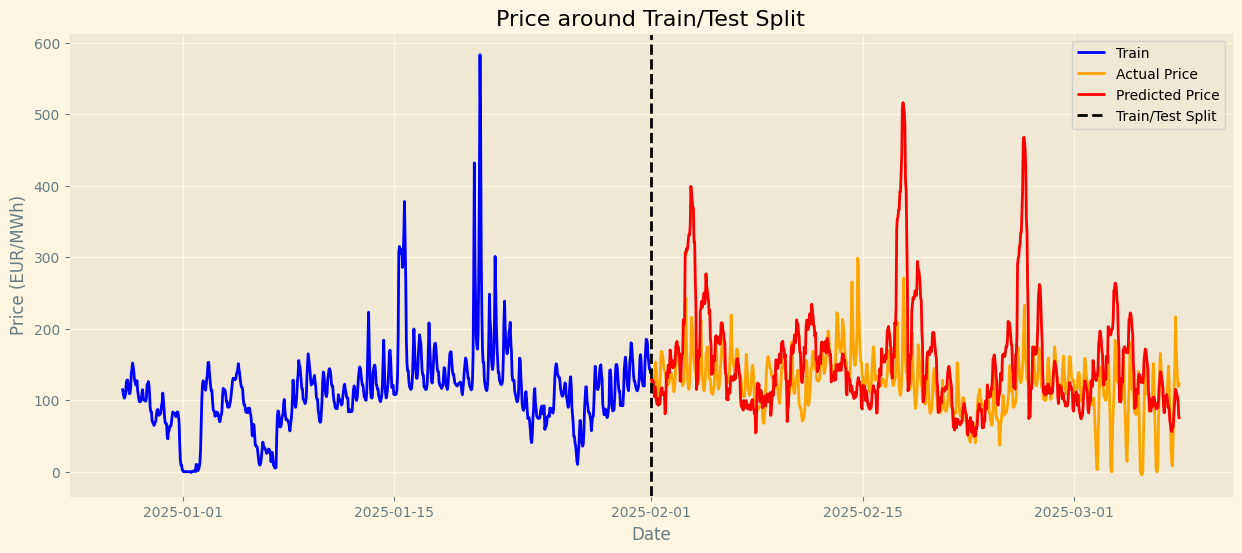

In [28]:
hours_xdays = 14 * 24

hours_xdays = pd.Timedelta(days=35)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
#pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv_full[::24]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]

plt.figure(figsize=(15, 6))
plt.plot(train_portion.index, train_portion['price'], label='Train', color='blue')
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color='orange')
plt.plot(pred_index[0:840], pred_values[0:840], label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

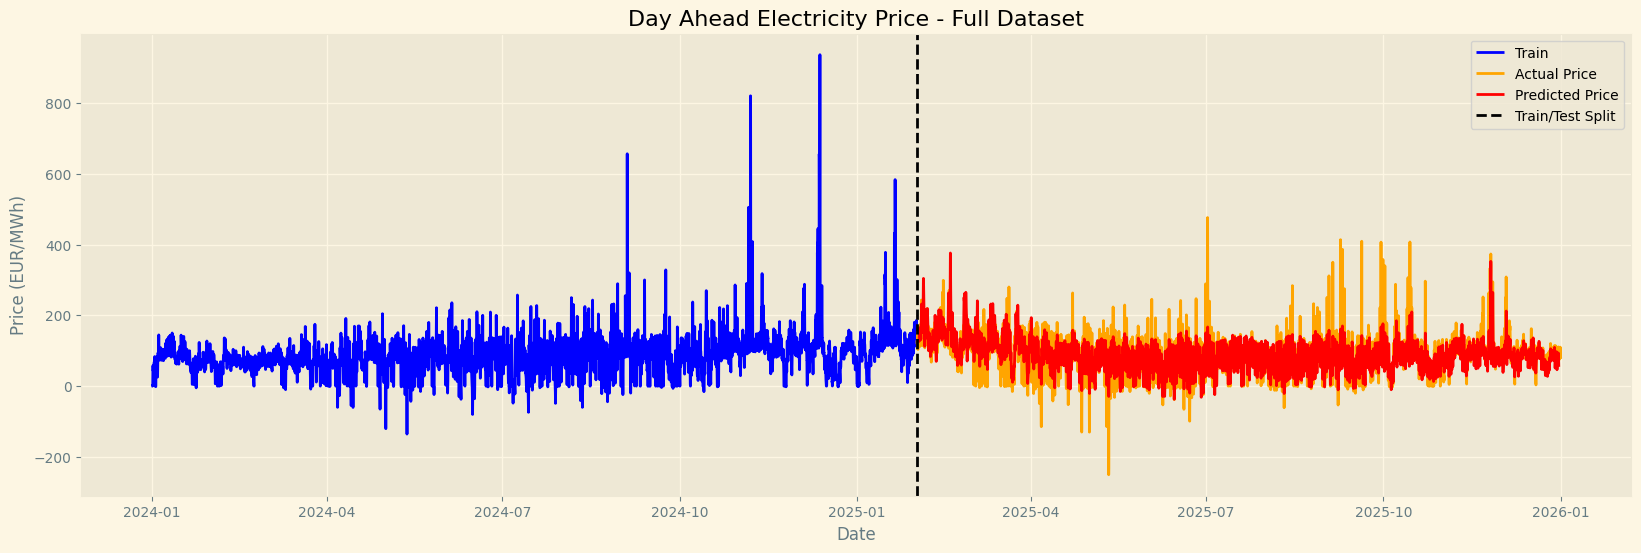

In [30]:
# Full prediction index covering entire test set
y_pred_t1 = y_pred_inv_full[:, 0]  # only t+1 from each sample
pred_index = test_df.index[lookback : lookback + len(y_pred_t1)]

plt.figure(figsize=(20, 6))
plt.plot(train_df.index, train_df['price'], label='Train', color='blue')
plt.plot(test_df.index, test_df['price'], label='Actual Price', color='orange')
plt.plot(pred_index, y_pred_t1, label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Day Ahead Electricity Price - Full Dataset')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Assessing RMSE and MAE

rmse = np.sqrt(mean_squared_error(y_test_inv_full.flatten(), y_pred_inv_full.flatten()))
mae = mean_absolute_error(y_test_inv_full.flatten(), y_pred_inv_full.flatten())

print(f'RMSE: {rmse:.2f} EUR/MWh')
print(f'MAE: {mae:.2f} EUR/MWh')

RMSE: 45.53 EUR/MWh
MAE: 30.91 EUR/MWh


In [20]:
# 1. Create a DataFrame from your arrays
export_df = pd.DataFrame({
    'time_stamp': pred_index,
    'pred_price': y_pred_plot
})

# 2. Export to CSV
# index=False prevents pandas from adding an extra 'unnamed' column for the row numbers
export_df.to_csv('E:\\nf_repo\\ai-for-energy\\notebook\\06_present_results\\lstm_2024_2025_predictions.csv', index=False)